In [166]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

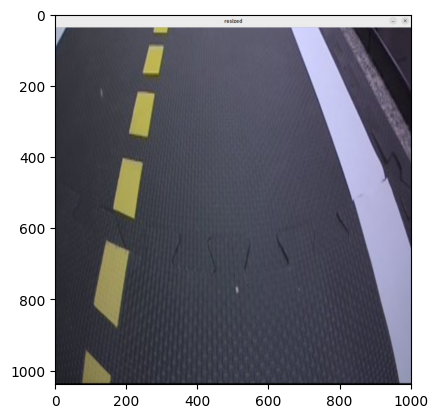

In [167]:
img = cv2.imread('/home/duckie5/Pictures/Screenshots/Screenshot from 2025-03-19 21-13-00.png')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
plt.imshow(img)

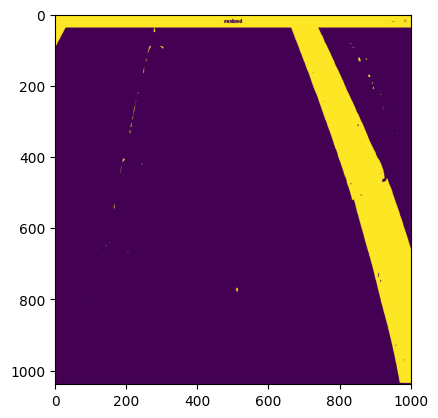

In [168]:
mask_white = cv2.inRange(hsv, 
                           (0,0, 150), 
                           (255,50,255))
plt.imshow(mask_white)

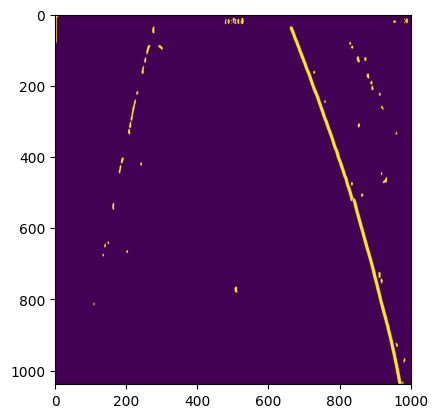

In [169]:
def get_x_for_driving( mask, distance, no_lane_value):
    mask = cv2.GaussianBlur(mask, (0,0), 1.3, 1.3)
    grad = cv2.Sobel(mask, cv2.CV_16S, 1, 0, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
    _,th1 = cv2.threshold(grad,127,255,cv2.THRESH_BINARY)

    a = []
    for row in range(distance-int(100), distance+100):
        if np.where(th1[row] == 255)[0].size == 0:
            continue
        else:
            a.append(np.where(th1[row] == 255)[0][-1])
    if len(a) >0:
        return np.mean(a),th1
    else:
        return no_lane_value,th1

x_w, th_w = get_x_for_driving(mask_white,800,0)
plt.imshow(th_w)

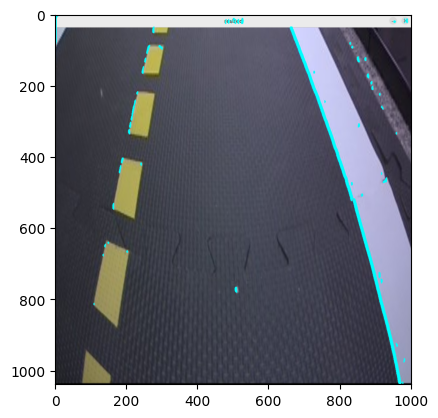

In [170]:
idx = np.where(th_w != 0)
img[idx] = (0,255,255)
plt.imshow(img) 

In [171]:
ys, xs = np.where(th_w[700:900] == 255)
points = np.array([xs, ys+700]).T
y = 0
points_y = []
points_mean = []

for p in points:
    y_t = p[1]
    
    if y_t > y + 10:
        y = y_t
        if len(points_y) > 0:
            points_mean.append((int(np.median(points_y)),int(y)))
        points_y = []
    
    points_y.append(p[0])

points_mean = np.array(points_mean)
points_mean

array([[889, 711],
       [892, 722],
       [897, 733],
       [900, 744],
       [903, 755],
       [904, 766],
       [903, 777],
       [907, 788],
       [911, 799],
       [914, 810],
       [916, 821],
       [920, 832],
       [923, 843],
       [926, 854],
       [929, 865],
       [932, 876],
       [934, 887],
       [937, 898]])

In [172]:
tck, u = splprep(np.array(points_mean).T, s=5)  
u_new = np.linspace(0, 1, 20)
x_spline, y_spline = splev(u_new, tck)

print(x_spline)
print(y_spline)

[888.91707054 891.78560091 895.61824451 899.28506563 901.72252095
 902.90960306 903.65847487 904.98581185 907.38264367 910.2453684
 913.26679667 916.23353947 919.09856013 921.8695905  924.55439577
 927.16074111 929.6963917  932.16911274 934.58666939 936.95682684]
[711.04239635 720.76720674 730.30438636 739.89552329 749.76541174
 759.87513798 769.97783875 779.88776521 789.63379051 799.38942284
 809.17093272 818.96948098 828.78375751 838.61493096 848.46417153
 858.33264941 868.22153478 878.13199783 888.06520874 898.02233769]


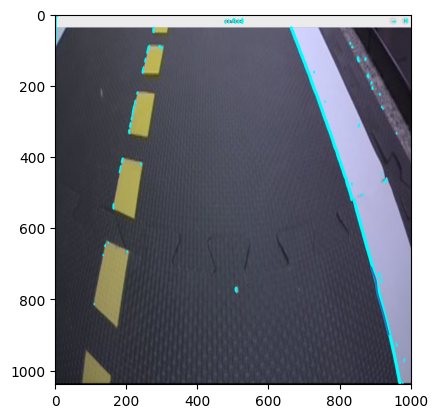

In [173]:
plt.plot(x_spline, y_spline, '-', label='Spline')
plt.imshow(img)

In [174]:
points_mean

array([[889, 711],
       [892, 722],
       [897, 733],
       [900, 744],
       [903, 755],
       [904, 766],
       [903, 777],
       [907, 788],
       [911, 799],
       [914, 810],
       [916, 821],
       [920, 832],
       [923, 843],
       [926, 854],
       [929, 865],
       [932, 876],
       [934, 887],
       [937, 898]])

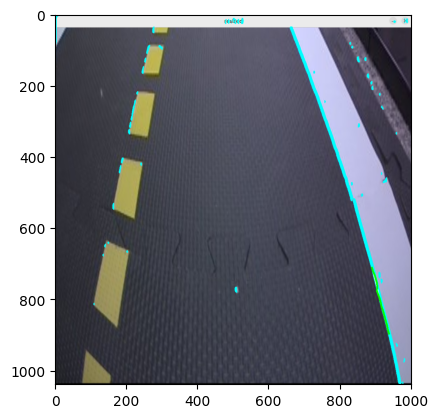

In [175]:
#cv2.drawContours(img,points_mean, 0, (255,255,255),2)
cv2.drawContours(img, [points_mean], 0, (255,255,255), 2)

cv2.polylines(img, 
              [points_mean], 
              isClosed = False,
              color = (0,255,0),
              thickness = 3, )

plt.imshow(img)

In [176]:
points_mean

array([[889, 711],
       [892, 722],
       [897, 733],
       [900, 744],
       [903, 755],
       [904, 766],
       [903, 777],
       [907, 788],
       [911, 799],
       [914, 810],
       [916, 821],
       [920, 832],
       [923, 843],
       [926, 854],
       [929, 865],
       [932, 876],
       [934, 887],
       [937, 898]])

In [183]:
poly = np.polyfit(points.T[1],points.T[0],3)
poly

array([-6.14508354e-05,  1.56058907e-01, -1.31028969e+02,  3.72696370e+04])

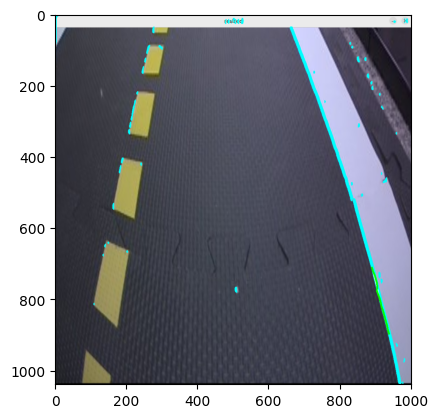

In [184]:
x = np.linspace(0,1000,10)
y = [np.polyval(poly, i) for i in x]
plt.imshow(img)
